# AlignSim: Paper-Style Semantic Reweighting Adapter for SimCSE

This notebook implements the parameter-free adapter from *Semantic Adapter for Universal Text Embeddings: Diagnosing and Mitigating Negation Blindness to Enhance Universality* for the multi-criterion AlignSim task.

It deliberately does **not** train SimCSE or a LoRA module. It:

1. freezes supervised SimCSE;
2. forms `(anchor, positive, criterion-negative)` triplets from AlignSim;
3. measures every embedding dimension's contribution to the desired margin;
4. constructs criterion-specific and shared weight vectors;
5. tunes only the reweighting strength on the development split;
6. evaluates once on the test split and STS-B;
7. saves weights, configurations, and result tables.

Expected CSV columns: `anchor`, `candidate`, and `relation_type` (or `relation`). Keep train/dev/test anchors disjoint.


In [1]:
!pip install -q "transformers>=4.46,<5" "datasets>=3,<4" pandas numpy scipy scikit-learn matplotlib tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 82.4 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.


In [2]:
import gc
import json
import random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Iterable, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from scipy.stats import spearmanr
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [3]:
@dataclass
class Config:
    base_model: str = "princeton-nlp/sup-simcse-bert-base-uncased"
    # How to turn base_model's hidden states into a sentence embedding.
    #   "simcse_pooler" -- AutoModel's pooler_output (dense + tanh over
    #       [CLS]). Correct for supervised SimCSE, matches how it was
    #       trained/evaluated. WRONG for BGE/MPNet/most other checkpoints.
    #   "cls" -- raw [CLS] token hidden state, no extra pooler transform.
    #       Correct for BGE (bge-base-en-v1.5 etc: "select the last hidden
    #       state of the first token" -- explicitly NOT the generic BERT
    #       pooler layer, which BGE never trained/tuned).
    #   "mean" -- mean-pooled token embeddings. Correct for MPNet
    #       (all-mpnet-base-v2) and most sentence-transformers checkpoints.
    # If you swap base_model, you MUST also set the matching pooling --
    # silently reusing "simcse_pooler" for a non-SimCSE checkpoint uses
    # that checkpoint's (often irrelevant/uncalibrated) BERT pooler head
    # instead of its actual trained embedding, and will give embeddings
    # that look plausible but are quietly wrong.
    pooling: str = "simcse_pooler"

    # Change these paths for your environment.
    train_csv: str = "/kaggle/input/datasets/aref111n/embedding/final_train.csv"
    dev_csv: str = "/kaggle/input/datasets/aref111n/embedding/final_dev.csv"
    test_csv: str = "/kaggle/input/datasets/aref111n/embedding/final_test.csv"
    output_dir: str = "/kaggle/working/alignsim_reweighting_adapter"

    max_length: int = 128
    encode_batch_size: int = 128
    eps: float = 0.05
    strengths: Tuple[float, ...] = tuple(np.arange(0.0, 5.01, 0.25))

    # Explicit (positive_relation, negative_relation) pair PER criterion,
    # matching the paper's C1-C4 definitions exactly -- NOT a shared
    # "best available positive" cascade applied to every negative type.
    # The previous cascade design (paraphrase > synonym > entailment,
    # applied uniformly across all negative relations) silently merged
    # C1 and C2: since paraphrase is usually available, "distinction"
    # triplets always used paraphrase as positive, so C2's actual
    # contrast (synonym vs distinction) was never tested as its own axis.
    criteria: Dict[str, Tuple[str, str]] = None  # filled in via __post_init__

    # "negation" and "contradiction" are extra axes beyond the paper's
    # official C1-C4 -- included as optional bonus criteria if your data
    # has them, not required for the core AlignSim comparison.
    extra_criteria: Dict[str, Tuple[str, str]] = None

    # Protect general semantic quality while selecting a shared adapter.
    stsb_allowed_dev_drop: float = 0.005

    def __post_init__(self):
        if self.criteria is None:
            self.criteria = {
                "C1_semantic_distinction": ("paraphrase", "distinction"),
                "C2_synonym_replacement":  ("synonym",    "distinction"),
                "C3_antonym_replacement":  ("paraphrase", "antonym"),
                "C4_sentence_jumbling":    ("paraphrase", "jumbled"),
            }
        if self.extra_criteria is None:
            self.extra_criteria = {
                "negation_extra":      ("paraphrase", "negation"),
                "contradiction_extra": ("paraphrase", "contradiction"),
            }

CFG = Config()
Path(CFG.output_dir).mkdir(parents=True, exist_ok=True)
print(json.dumps(asdict(CFG), indent=2))


{
  "base_model": "princeton-nlp/sup-simcse-bert-base-uncased",
  "pooling": "simcse_pooler",
  "train_csv": "/kaggle/input/datasets/aref111n/embedding/final_train.csv",
  "dev_csv": "/kaggle/input/datasets/aref111n/embedding/final_dev.csv",
  "test_csv": "/kaggle/input/datasets/aref111n/embedding/final_test.csv",
  "output_dir": "/kaggle/working/alignsim_reweighting_adapter",
  "max_length": 128,
  "encode_batch_size": 128,
  "eps": 0.05,
  "strengths": [
    0.0,
    0.25,
    0.5,
    0.75,
    1.0,
    1.25,
    1.5,
    1.75,
    2.0,
    2.25,
    2.5,
    2.75,
    3.0,
    3.25,
    3.5,
    3.75,
    4.0,
    4.25,
    4.5,
    4.75,
    5.0
  ],
  "criteria": {
    "C1_semantic_distinction": [
      "paraphrase",
      "distinction"
    ],
    "C2_synonym_replacement": [
      "synonym",
      "distinction"
    ],
    "C3_antonym_replacement": [
      "paraphrase",
      "antonym"
    ],
    "C4_sentence_jumbling": [
      "paraphrase",
      "jumbled"
    ]
  },
  "extra_cri

## 1. Load and validate AlignSim data

Relation aliases are normalized to match the names in your recent AlignSim notebook. Invalid same-text negative pairs and duplicate rows are removed. The notebook raises an error if anchors leak across splits.


In [4]:
RELATION_ALIASES = {
    "syn": "synonym", "synonyms": "synonym",
    "ant": "antonym", "antonyms": "antonym",
    "para": "paraphrase", "paraphrasing": "paraphrase",
    "jumbling": "jumbled", "jumble": "jumbled",
    "shuffle": "jumbled", "shuffled": "jumbled",
    "distinct": "distinction", "difference": "distinction",
    "contradictory": "contradiction", "contradict": "contradiction",
    "entails": "entailment",
}

def normalize_text(x) -> str:
    return "" if pd.isna(x) else " ".join(str(x).strip().lower().split())

def normalize_relation(x) -> str:
    value = normalize_text(x).replace("-", "_").replace(" ", "_")
    return RELATION_ALIASES.get(value, value)

def load_alignsim_csv(path: str, split_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "relation" in df.columns and "relation_type" not in df.columns:
        df = df.rename(columns={"relation": "relation_type"})
    required = {"anchor", "candidate", "relation_type"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{split_name} is missing columns: {sorted(missing)}")

    df = df.copy()
    df["anchor"] = df["anchor"].astype(str).str.strip()
    df["candidate"] = df["candidate"].astype(str).str.strip()
    df["relation_type"] = df["relation_type"].map(normalize_relation)
    df = df.drop_duplicates(["anchor", "candidate", "relation_type"])

    # Same-text check applies to whatever is used as a NEGATIVE across any
    # criterion (a candidate identical to the anchor can never be a valid
    # antonym/jumbled/distinction/negation/contradiction example).
    negative_set = {neg for _, neg in CFG.criteria.values()} | {neg for _, neg in CFG.extra_criteria.values()}
    same = df["anchor"].map(normalize_text) == df["candidate"].map(normalize_text)
    df = df.loc[~(same & df["relation_type"].isin(negative_set))].reset_index(drop=True)
    print(f"{split_name}: {len(df):,} rows, {df.anchor.nunique():,} anchors")
    display(df["relation_type"].value_counts())
    return df

train_df = load_alignsim_csv(CFG.train_csv, "train")
dev_df = load_alignsim_csv(CFG.dev_csv, "dev")
test_df = load_alignsim_csv(CFG.test_csv, "test")

split_anchors = {
    "train": set(train_df.anchor.map(normalize_text)),
    "dev": set(dev_df.anchor.map(normalize_text)),
    "test": set(test_df.anchor.map(normalize_text)),
}
for left, right in (("train", "dev"), ("train", "test"), ("dev", "test")):
    overlap = split_anchors[left] & split_anchors[right]
    if overlap:
        raise ValueError(f"Anchor leakage between {left}/{right}: {len(overlap)} anchors")
print("Anchor-disjointness verified.")


train: 67,389 rows, 7,999 anchors


relation_type
paraphrase       7999
synonym          7999
antonym          7999
entailment       7999
neutral          7999
contradiction    7999
jumbled          7999
distinction      7999
negation         3397
Name: count, dtype: int64

dev: 8,425 rows, 1,000 anchors


relation_type
paraphrase       1000
synonym          1000
antonym          1000
entailment       1000
neutral          1000
contradiction    1000
jumbled          1000
distinction      1000
negation          425
Name: count, dtype: int64

test: 8,433 rows, 1,001 anchors


relation_type
paraphrase       1001
synonym          1001
antonym          1001
entailment       1001
neutral          1001
contradiction    1001
jumbled          1001
distinction      1001
negation          425
Name: count, dtype: int64

Anchor-disjointness verified.


## 2. Build criterion triplets

For every anchor and criterion, the first available positive is chosen using this priority: paraphrase, synonym, entailment. Each criterion is kept separate so we can diagnose conflicts between semantic axes before constructing one shared adapter.


In [5]:
def build_triplets(
    df: pd.DataFrame,
    positive_relation: str,
    negative_relation: str,
) -> pd.DataFrame:
    """Explicit (positive_relation, negative_relation) per criterion --
    e.g. C2 uses "synonym" as positive, NOT a cascade that falls back to
    paraphrase whenever it's available. This is what makes C1 and C2
    genuinely different axes instead of both collapsing onto paraphrase."""
    rows = []
    for anchor, group in df.groupby("anchor", sort=False):
        positives = group.loc[group.relation_type == positive_relation, "candidate"]
        negatives = group.loc[group.relation_type == negative_relation, "candidate"]
        if len(positives) and len(negatives):
            rows.append({
                "anchor": anchor,
                "positive": positives.iloc[0],
                "negative": negatives.iloc[0],
                "positive_relation": positive_relation,
                "negative_relation": negative_relation,
            })
    return pd.DataFrame(rows)

ALL_CRITERIA = {**CFG.criteria, **CFG.extra_criteria}

triplets = {split: {} for split in ("train", "dev", "test")}
for split, df in (("train", train_df), ("dev", dev_df), ("test", test_df)):
    for name, (pos_rel, neg_rel) in ALL_CRITERIA.items():
        current = build_triplets(df, pos_rel, neg_rel)
        if len(current):
            triplets[split][name] = current

coverage = pd.DataFrame({
    split: {name: len(triplets[split].get(name, []))
            for name in ALL_CRITERIA}
    for split in ("train", "dev", "test")
}).fillna(0).astype(int)
display(coverage)

# Core C1-C4 must all be usable; extra_criteria are optional (dropped
# silently if the data doesn't support them, rather than failing the run).
usable_relations = [name for name in CFG.criteria
                    if all(name in triplets[s] and len(triplets[s][name]) > 0
                           for s in ("train", "dev", "test"))]
missing_core = set(CFG.criteria) - set(usable_relations)
if missing_core:
    raise ValueError(f"Core criteria missing usable train/dev/test triplets: {missing_core}")

usable_extra = [name for name in CFG.extra_criteria
                if all(name in triplets[s] and len(triplets[s][name]) > 0
                       for s in ("train", "dev", "test"))]
usable_relations += usable_extra
print("Usable criteria (core C1-C4 + any usable extras):", usable_relations)


,train,dev,test
C1_semantic_distinction,7999,1000,1001
C2_synonym_replacement,7999,1000,1001
C3_antonym_replacement,7999,1000,1001
C4_sentence_jumbling,7999,1000,1001
negation_extra,3397,425,425
contradiction_extra,7999,1000,1001


Usable criteria (core C1-C4 + any usable extras): ['C1_semantic_distinction', 'C2_synonym_replacement', 'C3_antonym_replacement', 'C4_sentence_jumbling', 'negation_extra', 'contradiction_extra']


## 3. Frozen encoder (pooling matches your chosen base_model)

`CFG.pooling` selects how hidden states become a sentence embedding.
The official SimCSE BERT checkpoint uses `pooler_output` (dense + tanh
over `[CLS]`) -- correct for `princeton-nlp/sup-simcse-bert-base-uncased`.
If you swap `base_model` to BGE, set `pooling="cls"`; for MPNet or most
sentence-transformers checkpoints, set `pooling="mean"`. Reusing the
SimCSE pooler for a different checkpoint silently uses that checkpoint's
own (often irrelevant) BERT pooler head instead of its real trained
embedding.

In [6]:
class FrozenEncoder:
    """Renamed from FrozenSimCSE -- now supports the three pooling modes
    a base checkpoint might actually need (see Config.pooling's docstring
    above). Using the wrong mode for a given base_model gives embeddings
    that run without error but are quietly incorrect."""

    def __init__(self, model_name: str, max_length: int = 128, pooling: str = "simcse_pooler"):
        if pooling not in ("simcse_pooler", "cls", "mean"):
            raise ValueError(f"Unknown pooling {pooling!r}; choose simcse_pooler/cls/mean")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(DEVICE)
        self.model.eval()
        self.max_length = max_length
        self.pooling = pooling
        for parameter in self.model.parameters():
            parameter.requires_grad = False

    def _pool(self, result, attention_mask):
        if self.pooling == "simcse_pooler":
            # BERT's own dense+tanh pooler head over [CLS] -- correct for
            # supervised SimCSE, WRONG for checkpoints that never trained
            # or calibrated that head (e.g. BGE, MPNet).
            return result.pooler_output
        if self.pooling == "cls":
            # Raw [CLS] hidden state, no extra transform -- what BGE
            # actually uses.
            return result.last_hidden_state[:, 0]
        # mean pooling over real (non-padding) tokens -- what MPNet /
        # most sentence-transformers checkpoints use.
        mask = attention_mask.unsqueeze(-1).float()
        summed = (result.last_hidden_state * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

    @torch.inference_mode()
    def encode(self, texts: Iterable[str], batch_size: int = 128) -> np.ndarray:
        texts = list(texts)
        outputs = []
        for start in tqdm(range(0, len(texts), batch_size), desc="encoding", leave=False):
            batch = texts[start:start + batch_size]
            tokens = self.tokenizer(
                batch, padding=True, truncation=True,
                max_length=self.max_length, return_tensors="pt"
            )
            tokens = {k: v.to(DEVICE) for k, v in tokens.items()}
            result = self.model(**tokens, return_dict=True)
            embeddings = self._pool(result, tokens["attention_mask"])
            embeddings = torch.nn.functional.normalize(embeddings.float(), p=2, dim=-1)
            outputs.append(embeddings.cpu().numpy())
        return np.concatenate(outputs, axis=0).astype(np.float32)

encoder = FrozenEncoder(CFG.base_model, CFG.max_length, pooling=CFG.pooling)
print(f"Pooling mode: {CFG.pooling}")
print("Embedding dimension:", encoder.model.config.hidden_size)
print("Trainable parameters:", sum(p.numel() for p in encoder.model.parameters() if p.requires_grad))


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Pooling mode: simcse_pooler
Embedding dimension: 768
Trainable parameters: 0


## 4. Cache frozen embeddings

Every unique sentence is encoded once. The cache makes the complete strength grid inexpensive because no model forward pass is repeated while tuning.


In [7]:
all_texts = []
for split in triplets.values():
    for frame in split.values():
        for column in ("anchor", "positive", "negative"):
            all_texts.extend(frame[column].astype(str).tolist())
unique_texts = list(dict.fromkeys(all_texts))
print(f"Encoding {len(unique_texts):,} unique AlignSim sentences...")
matrix = encoder.encode(unique_texts, CFG.encode_batch_size)
embedding_cache = dict(zip(unique_texts, matrix))

def cached_matrix(texts: Iterable[str]) -> np.ndarray:
    return np.stack([embedding_cache[str(t)] for t in texts]).astype(np.float32)

def triplet_embeddings(frame: pd.DataFrame):
    return (
        cached_matrix(frame.anchor),
        cached_matrix(frame.positive),
        cached_matrix(frame.negative),
    )


Encoding 73,872 unique AlignSim sentences...


encoding:   0%|          | 0/578 [00:00<?, ?it/s]

## 5. Learn paper-style dimension contributions

For normalized embeddings, dimension (k)'s contribution for example (i) is

\[
v_i^k=(e_{T_i}^ke_{P_i}^k)-(e_{T_i}^ke_{N_i}^k).
\]

The adapter stores only the average vector (V). There is no optimizer, backpropagation, epoch, or update to SimCSE.


In [8]:
def learn_contribution(frame: pd.DataFrame) -> np.ndarray:
    anchor, positive, negative = triplet_embeddings(frame)
    v = (anchor * positive - anchor * negative).mean(axis=0)
    # Paper-style rescaling by max(|V|) -- NOT max(V) (raw signed max).
    # Bug in the original: if the most extreme component happens to be
    # negative (v's max is <=0, e.g. every dimension mildly favors the
    # negative match on average -- exactly what a genuinely hard
    # criterion like antonym can look like), `if max_v > 0` skipped
    # rescaling entirely, leaving v at its tiny raw magnitude. Every
    # softmax(strength * v) in the whole strength grid then comes out
    # ~uniform regardless of strength, making the grid search pointless
    # for that criterion -- a silent failure mode, not an explicit error.
    max_abs_v = float(np.abs(v).max())
    if max_abs_v > 1e-12:
        v = v / max_abs_v
    return v.astype(np.float32)

def softmax_np(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    x = x - np.max(x)
    exp_x = np.exp(x)
    return (exp_x / exp_x.sum()).astype(np.float32)

def weights_from_contribution(v: np.ndarray, strength: float) -> np.ndarray:
    return softmax_np(float(strength) * v)

def weighted_cosine(x: np.ndarray, y: np.ndarray, weights: np.ndarray,
                    eps: float = 1e-12) -> np.ndarray:
    # Direct weighted cosine. Equivalent to applying sqrt(weights), then cosine.
    numerator = np.sum(weights * x * y, axis=-1)
    x_norm = np.sqrt(np.sum(weights * x * x, axis=-1))
    y_norm = np.sqrt(np.sum(weights * y * y, axis=-1))
    return numerator / np.maximum(x_norm * y_norm, eps)

def adapt_embeddings(x: np.ndarray, weights: np.ndarray) -> np.ndarray:
    adapted = x * np.sqrt(weights)
    return adapted / np.maximum(np.linalg.norm(adapted, axis=-1, keepdims=True), 1e-12)

criterion_v = {
    relation: learn_contribution(triplets["train"][relation])
    for relation in usable_relations
}
print("Learned contribution vectors:", {k: v.shape for k, v in criterion_v.items()})


Learned contribution vectors: {'C1_semantic_distinction': (768,), 'C2_synonym_replacement': (768,), 'C3_antonym_replacement': (768,), 'C4_sentence_jumbling': (768,), 'negation_extra': (768,), 'contradiction_extra': (768,)}


## 6. Diagnose agreement and conflict between AlignSim axes

Positive correlation means two criteria prefer similar embedding dimensions. Negative correlation exposes a trade-off that a single shared adapter must balance.


,C1_semantic_distinction,C2_synonym_replacement,C3_antonym_replacement,C4_sentence_jumbling,negation_extra,contradiction_extra
C1_semantic_distinction,1.000,0.992,0.127,0.254,0.001,0.670
C2_synonym_replacement,0.992,1.000,0.096,0.237,-0.014,0.657
C3_antonym_replacement,0.127,0.096,1.000,0.065,0.178,0.289
C4_sentence_jumbling,0.254,0.237,0.065,1.000,-0.008,-0.017
negation_extra,0.001,-0.014,0.178,-0.008,1.000,0.284
contradiction_extra,0.670,0.657,0.289,-0.017,0.284,1.000


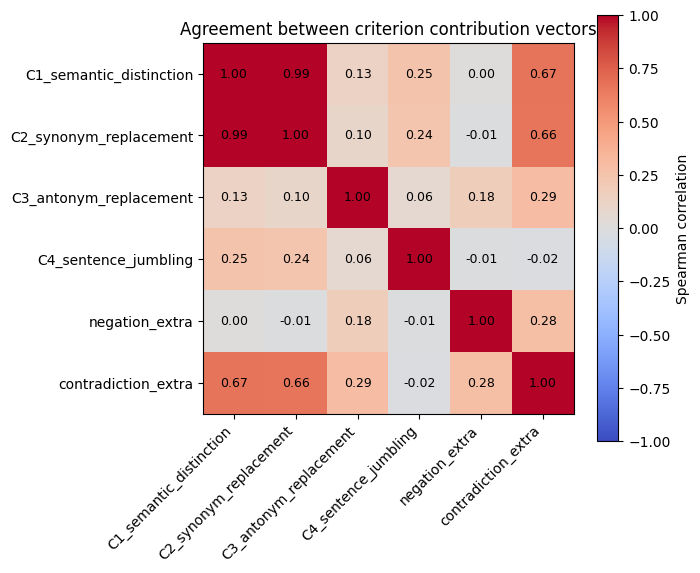

In [9]:
relation_list = list(criterion_v)
agreement = np.zeros((len(relation_list), len(relation_list)), dtype=float)
for i, left in enumerate(relation_list):
    for j, right in enumerate(relation_list):
        agreement[i, j] = spearmanr(criterion_v[left], criterion_v[right]).correlation

agreement_df = pd.DataFrame(agreement, index=relation_list, columns=relation_list)
display(agreement_df.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(agreement, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(relation_list)), relation_list, rotation=45, ha="right")
ax.set_yticks(range(len(relation_list)), relation_list)
for i in range(len(relation_list)):
    for j in range(len(relation_list)):
        ax.text(j, i, f"{agreement[i,j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(image, ax=ax, label="Spearman correlation")
ax.set_title("Agreement between criterion contribution vectors")
plt.tight_layout()
plt.show()


## 7. Create one shared AlignSim adapter

Each criterion vector is L2-normalized before averaging so a criterion with a larger raw magnitude cannot dominate merely because of scale.


In [10]:
def unit_vector(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    return v / max(float(np.linalg.norm(v)), eps)

shared_v = np.mean([unit_vector(criterion_v[r]) for r in usable_relations], axis=0)
shared_v = shared_v / max(float(np.max(shared_v)), 1e-12)
shared_v = shared_v.astype(np.float32)

all_v = {**criterion_v, "shared": shared_v}
print("Shared vector shape:", shared_v.shape)


Shared vector shape: (768,)


## 8. Tune strength on development data only

Criterion-specific adapters maximize their own development pass rate. The shared adapter maximizes the worst criterion pass rate first, then the macro pass rate and mean margin. This prevents an easy axis from hiding failure on a difficult axis.


In [11]:
def evaluate_frame(frame: pd.DataFrame, weights: np.ndarray, eps: float = CFG.eps) -> Dict[str, float]:
    anchor, positive, negative = triplet_embeddings(frame)
    pos_sim = weighted_cosine(anchor, positive, weights)
    neg_sim = weighted_cosine(anchor, negative, weights)
    margins = pos_sim - neg_sim
    return {
        "n": len(frame),
        "positive_similarity": float(pos_sim.mean()),
        "negative_similarity": float(neg_sim.mean()),
        "mean_margin": float(margins.mean()),
        "pass_rate": float((margins > eps).mean()),
    }

def evaluate_all_criteria(split: str, weights: np.ndarray) -> pd.DataFrame:
    rows = []
    for relation in usable_relations:
        metrics = evaluate_frame(triplets[split][relation], weights)
        rows.append({"criterion": relation, **metrics})
    return pd.DataFrame(rows)

search_rows = []
best_strengths = {}

# Criterion-specific grid searches
for target in usable_relations:
    target_rows = []
    for strength in CFG.strengths:
        weights = weights_from_contribution(criterion_v[target], strength)
        metrics = evaluate_frame(triplets["dev"][target], weights)
        row = {"adapter": target, "strength": strength, **metrics}
        target_rows.append(row)
        search_rows.append(row)
    best = max(target_rows, key=lambda r: (r["pass_rate"], r["mean_margin"], -r["strength"]))
    best_strengths[target] = float(best["strength"])

# Shared adapter grid search
shared_rows = []
for strength in CFG.strengths:
    weights = weights_from_contribution(shared_v, strength)
    table = evaluate_all_criteria("dev", weights)
    row = {
        "adapter": "shared", "strength": strength,
        "n": int(table.n.sum()),
        "positive_similarity": float(table.positive_similarity.mean()),
        "negative_similarity": float(table.negative_similarity.mean()),
        "mean_margin": float(table.mean_margin.mean()),
        "pass_rate": float(table.pass_rate.mean()),
        "worst_pass_rate": float(table.pass_rate.min()),
    }
    shared_rows.append(row)
    search_rows.append(row)
best_shared = max(shared_rows, key=lambda r: (
    r["worst_pass_rate"], r["pass_rate"], r["mean_margin"], -r["strength"]
))
best_strengths["shared"] = float(best_shared["strength"])

search_df = pd.DataFrame(search_rows)
display(search_df)
print("Selected strengths:", best_strengths)


,adapter,strength,n,positive_similarity,negative_similarity,mean_margin,pass_rate,worst_pass_rate
0,C1_semantic_distinction,0.00,1000,0.898214,-0.018566,0.916780,1.000000,NaN
1,C1_semantic_distinction,0.25,1000,0.898511,-0.020165,0.918676,1.000000,NaN
2,C1_semantic_distinction,0.50,1000,0.898818,-0.021843,0.920661,1.000000,NaN
3,C1_semantic_distinction,0.75,1000,0.899135,-0.023608,0.922743,1.000000,NaN
4,C1_semantic_distinction,1.00,1000,0.899462,-0.025468,0.924930,1.000000,NaN
...,...,...,...,...,...,...,...,...
142,shared,4.00,5425,0.917484,0.471882,0.445602,0.733167,0.341
143,shared,4.25,5425,0.917883,0.470731,0.447151,0.733441,0.340
144,shared,4.50,5425,0.918289,0.469511,0.448778,0.734500,0.341
145,shared,4.75,5425,0.918702,0.468219,0.450483,0.734833,0.340


Selected strengths: {'C1_semantic_distinction': 5.0, 'C2_synonym_replacement': 5.0, 'C3_antonym_replacement': 5.0, 'C4_sentence_jumbling': 5.0, 'negation_extra': 5.0, 'contradiction_extra': 4.5, 'shared': 3.25}


## 9. Optional STS-B preservation check

This cell downloads STS-B and evaluates the selected adapters without fitting anything to its test labels. If the shared adapter loses more than the configured development tolerance, select the best weaker strength satisfying the constraint.


In [12]:
stsb = load_dataset("glue", "stsb")

def encode_stsb_split(split_name: str):
    split = stsb[split_name]
    sentences = list(dict.fromkeys(list(split["sentence1"]) + list(split["sentence2"])))
    missing = [s for s in sentences if s not in embedding_cache]
    if missing:
        new_matrix = encoder.encode(missing, CFG.encode_batch_size)
        embedding_cache.update(dict(zip(missing, new_matrix)))
    e1 = cached_matrix(split["sentence1"])
    e2 = cached_matrix(split["sentence2"])
    labels = np.asarray(split["label"], dtype=np.float32)
    return e1, e2, labels

stsb_dev = encode_stsb_split("validation")
stsb_test = encode_stsb_split("test")

def evaluate_stsb_cached(data, weights):
    e1, e2, labels = data
    scores = weighted_cosine(e1, e2, weights)
    return float(spearmanr(scores, labels).correlation)

uniform_weights = weights_from_contribution(shared_v, 0.0)
base_stsb_dev = evaluate_stsb_cached(stsb_dev, uniform_weights)
print(f"Base STS-B dev Spearman: {base_stsb_dev:.4f}")

# Re-select shared strength under STS-B preservation constraint.
qualified = []
for row in shared_rows:
    weights = weights_from_contribution(shared_v, row["strength"])
    stsb_score = evaluate_stsb_cached(stsb_dev, weights)
    row["stsb_dev"] = stsb_score
    row["stsb_drop"] = base_stsb_dev - stsb_score
    if row["stsb_drop"] <= CFG.stsb_allowed_dev_drop:
        qualified.append(row)

if qualified:
    best_shared = max(qualified, key=lambda r: (
        r["worst_pass_rate"], r["pass_rate"], r["mean_margin"], -r["strength"]
    ))
    best_strengths["shared"] = float(best_shared["strength"])
else:
    print("Warning: no nonzero shared setting satisfies STS-B tolerance; using strength 0.")
    best_strengths["shared"] = 0.0

display(pd.DataFrame(shared_rows))
print("Final shared strength after STS-B constraint:", best_strengths["shared"])


README.md: 0.00B [00:00, ?B/s]

stsb/train-00000-of-00001.parquet:   0%|          | 0.00/502k [00:00<?, ?B/s]

stsb/validation-00000-of-00001.parquet:   0%|          | 0.00/151k [00:00<?, ?B/s]

stsb/test-00000-of-00001.parquet:   0%|          | 0.00/114k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

...

encoding:   0%|          | 0/23 [00:00<?, ?it/s]

encoding:   0%|          | 0/20 [00:00<?, ?it/s]

Base STS-B dev Spearman: 0.8619


,adapter,strength,n,positive_similarity,negative_similarity,mean_margin,pass_rate,worst_pass_rate,stsb_dev,stsb_drop
0,shared,0.00,5425,0.912872,0.483025,0.429847,0.724784,0.293,0.861850,0.000000
1,shared,0.25,5425,0.913063,0.482604,0.430459,0.725843,0.298,0.861794,0.000056
2,shared,0.50,5425,0.913265,0.482159,0.431106,0.726569,0.301,0.861752,0.000099
3,shared,0.75,5425,0.913479,0.481688,0.431791,0.726843,0.305,0.861727,0.000123
4,shared,1.00,5425,0.913705,0.481188,0.432517,0.726784,0.307,0.861568,0.000283
5,shared,1.25,5425,0.913944,0.480657,0.433287,0.727284,0.311,0.861442,0.000409
6,shared,1.50,5425,0.914196,0.480093,0.434103,0.726833,0.314,0.861365,0.000486
7,shared,1.75,5425,0.914461,0.479492,0.434970,0.728108,0.324,0.861211,0.000640
8,shared,2.00,5425,0.914741,0.478851,0.435890,0.728157,0.329,0.861036,0.000814
9,shared,2.25,5425,0.915035,0.478167,0.436868,0.728324,0.330,0.860858,0.000993


Final shared strength after STS-B constraint: 3.25


## 10. Final test evaluation

The test split is touched only after all strengths have been selected. We report the frozen SimCSE baseline, each criterion-specific adapter, and the shared multi-criterion adapter.


In [13]:
final_rows = []

# Strength 0 produces uniform weighted cosine, equivalent to ordinary cosine.
baseline_weights = weights_from_contribution(shared_v, 0.0)
baseline_table = evaluate_all_criteria("test", baseline_weights)
for _, row in baseline_table.iterrows():
    final_rows.append({"adapter": "frozen_simcse", "strength": 0.0, **row.to_dict()})

for adapter_name in usable_relations + ["shared"]:
    strength = best_strengths[adapter_name]
    weights = weights_from_contribution(all_v[adapter_name], strength)
    table = evaluate_all_criteria("test", weights)
    for _, row in table.iterrows():
        final_rows.append({"adapter": adapter_name, "strength": strength, **row.to_dict()})

final_results = pd.DataFrame(final_rows)
display(final_results)

pass_pivot = final_results.pivot(index="adapter", columns="criterion", values="pass_rate")
margin_pivot = final_results.pivot(index="adapter", columns="criterion", values="mean_margin")
print("Test pass rates")
display(pass_pivot.style.format("{:.1%}"))
print("Test mean margins")
display(margin_pivot.style.format("{:+.4f}"))

# STS-B test labels in GLUE are hidden (-1), so report dev unless local labels exist.
stsb_rows = []
for adapter_name in ["frozen_simcse"] + usable_relations + ["shared"]:
    if adapter_name == "frozen_simcse":
        weights, strength = baseline_weights, 0.0
    else:
        strength = best_strengths[adapter_name]
        weights = weights_from_contribution(all_v[adapter_name], strength)
    stsb_rows.append({
        "adapter": adapter_name,
        "strength": strength,
        "stsb_dev_spearman": evaluate_stsb_cached(stsb_dev, weights),
    })
stsb_results = pd.DataFrame(stsb_rows)
display(stsb_results)


,adapter,strength,criterion,n,positive_similarity,negative_similarity,mean_margin,pass_rate
0,frozen_simcse,0.00,C1_semantic_distinction,1001,0.899403,-0.021670,0.921073,1.000000
1,frozen_simcse,0.00,C2_synonym_replacement,1001,0.975557,-0.021670,0.997227,1.000000
2,frozen_simcse,0.00,C3_antonym_replacement,1001,0.899403,0.899826,-0.000423,0.321678
3,frozen_simcse,0.00,C4_sentence_jumbling,1001,0.899403,0.884731,0.014672,0.364635
4,frozen_simcse,0.00,negation_extra,425,0.902876,0.810270,0.092607,0.694118
5,frozen_simcse,0.00,contradiction_extra,1001,0.899403,0.352346,0.547057,0.982018
6,C1_semantic_distinction,5.00,C1_semantic_distinction,1001,0.908041,-0.079206,0.987247,1.000000
7,C1_semantic_distinction,5.00,C2_synonym_replacement,1001,0.977324,-0.079206,1.056530,1.000000
8,C1_semantic_distinction,5.00,C3_antonym_replacement,1001,0.908041,0.905927,0.002113,0.308691
9,C1_semantic_distinction,5.00,C4_sentence_jumbling,1001,0.908041,0.894036,0.014005,0.346653


Test pass rates


criterion,C1_semantic_distinction,C2_synonym_replacement,C3_antonym_replacement,C4_sentence_jumbling,contradiction_extra,negation_extra
adapter,,,,,,
C1_semantic_distinction,100.0%,100.0%,30.9%,34.7%,98.1%,66.4%
C2_synonym_replacement,100.0%,100.0%,31.3%,34.9%,98.1%,66.6%
C3_antonym_replacement,100.0%,100.0%,46.8%,33.5%,97.6%,64.5%
C4_sentence_jumbling,100.0%,100.0%,31.3%,38.6%,98.1%,65.9%
contradiction_extra,100.0%,100.0%,33.4%,34.3%,98.0%,68.2%
frozen_simcse,100.0%,100.0%,32.2%,36.5%,98.2%,69.4%
negation_extra,100.0%,100.0%,29.8%,32.7%,98.1%,80.2%
shared,100.0%,100.0%,36.4%,34.8%,98.0%,70.6%


Test mean margins


criterion,C1_semantic_distinction,C2_synonym_replacement,C3_antonym_replacement,C4_sentence_jumbling,contradiction_extra,negation_extra
adapter,,,,,,
C1_semantic_distinction,+0.9872,+1.0565,+0.0021,+0.0140,+0.5373,+0.0859
C2_synonym_replacement,+0.9830,+1.0528,+0.0021,+0.0140,+0.5370,+0.0857
C3_antonym_replacement,+0.9459,+1.0193,+0.0736,+0.0115,+0.5530,+0.0809
C4_sentence_jumbling,+0.9894,+1.0618,+0.0005,+0.0215,+0.5205,+0.0871
contradiction_extra,+0.9310,+1.0022,+0.0045,+0.0134,+0.5577,+0.0927
frozen_simcse,+0.9211,+0.9972,-0.0004,+0.0147,+0.5471,+0.0926
negation_extra,+0.9066,+0.9777,+0.0020,+0.0111,+0.5620,+0.1759
shared,+0.9462,+1.0189,+0.0142,+0.0141,+0.5466,+0.1007


,adapter,strength,stsb_dev_spearman
0,frozen_simcse,0.00,0.861850
1,C1_semantic_distinction,5.00,0.854242
2,C2_synonym_replacement,5.00,0.854973
3,C3_antonym_replacement,5.00,0.827293
4,C4_sentence_jumbling,5.00,0.848114
5,negation_extra,5.00,0.840689
6,contradiction_extra,4.50,0.857597
7,shared,3.25,0.859482


## 11. Compare adapter geometry and save all artifacts

The `.npz` file contains contribution vectors and final weight vectors. Reuse the weight vector only with the exact same SimCSE checkpoint and pooling strategy.


In [14]:
weights_to_save = {
    f"contribution_{name}": vector for name, vector in all_v.items()
}
for name, vector in all_v.items():
    weights_to_save[f"weights_{name}"] = weights_from_contribution(
        vector, best_strengths[name]
    )

output_dir = Path(CFG.output_dir)
np.savez_compressed(output_dir / "alignsim_adapter_weights.npz", **weights_to_save)
final_results.to_csv(output_dir / "alignsim_test_results.csv", index=False)
stsb_results.to_csv(output_dir / "alignsim_stsb_results.csv", index=False)
search_df.to_csv(output_dir / "alignsim_strength_search.csv", index=False)
agreement_df.to_csv(output_dir / "alignsim_axis_agreement.csv")

metadata = {
    "config": asdict(CFG),
    "usable_relations": usable_relations,
    "best_strengths": best_strengths,
    "embedding_dimension": int(encoder.model.config.hidden_size),
    "pooling": "transformers AutoModel pooler_output",
    "weight_application": "direct weighted cosine / sqrt(weight) transformed embedding",
    "training": "No gradient descent; contribution vectors estimated from train split",
}
with open(output_dir / "alignsim_adapter_metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print("Saved:")
for path in sorted(output_dir.glob("alignsim_*")):
    print(" -", path)


Saved:
 - /kaggle/working/alignsim_reweighting_adapter/alignsim_adapter_metadata.json
 - /kaggle/working/alignsim_reweighting_adapter/alignsim_adapter_weights.npz
 - /kaggle/working/alignsim_reweighting_adapter/alignsim_axis_agreement.csv
 - /kaggle/working/alignsim_reweighting_adapter/alignsim_strength_search.csv
 - /kaggle/working/alignsim_reweighting_adapter/alignsim_stsb_results.csv
 - /kaggle/working/alignsim_reweighting_adapter/alignsim_test_results.csv


## 12. Inference example

Use the shared adapter when the downstream application does not specify a semantic axis. Use a criterion-specific adapter only when the application explicitly requires that sensitivity.


In [15]:
def encode_with_adapter(
    texts: Sequence[str],
    adapter_name: str = "shared",
    batch_size: int = CFG.encode_batch_size,
) -> np.ndarray:
    if adapter_name not in all_v:
        raise KeyError(f"Unknown adapter {adapter_name!r}; choose from {list(all_v)}")
    base_embeddings = encoder.encode(texts, batch_size)
    weights = weights_from_contribution(
        all_v[adapter_name], best_strengths[adapter_name]
    )
    return adapt_embeddings(base_embeddings, weights)

examples = [
    "The patient has a fever.",
    "The patient is suffering from fever.",
    "The patient does not have a fever.",
]
adapted = encode_with_adapter(examples, "shared")
similarities = adapted @ adapted.T
display(pd.DataFrame(similarities, index=examples, columns=examples).round(4))


encoding:   0%|          | 0/1 [00:00<?, ?it/s]

,The patient has a fever.,The patient is suffering from fever.,The patient does not have a fever.
The patient has a fever.,1.0000,0.9861,0.7528
The patient is suffering from fever.,0.9861,1.0000,0.7125
The patient does not have a fever.,0.7528,0.7125,1.0000


## Suggested ablation table for the AlignSim paper

Report at least:

- frozen SimCSE;
- each single-axis reweighting adapter;
- the shared AlignSim adapter;
- your existing LoRA AlignSim system;
- optional LoRA + post-hoc shared reweighting.

For every model, report per-criterion pass rate/margin, STS-B, MRPC, QQP, PAWS, and your chosen MTEB tasks. The adapter learned here is a distinct parameter-free experimental branch, not a replacement for the LoRA baseline.


## 13. Downstream evaluation battery: MR, CR, SUBJ, MPQA, SST2, TREC, retrieval, reranking

Evaluates `encode_with_adapter()` (already defined above) across the
frozen baseline and every fitted adapter (`usable_relations` + `"shared"`)
on:

- **MR / CR / SUBJ / MPQA / SST2 / TREC** -- 5-fold CV accuracy of a
  logistic-regression linear probe on top of frozen embeddings (the
  standard sentence-embedding classification-probe protocol).
- **Retrieval** (SciFact / NFCorpus / ArguAna) and **Reranking**
  (SummEval / StackOverflowDupQuestions / SciDocsRR) via the real `mteb`
  package, if installed.

These never touch `encoder`'s weights -- exactly like every other table
in this notebook, only the post-hoc reweighting differs across rows.

In [16]:
!pip install -q "mteb>=1.14,<2" scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 8.3 MB/s eta 0:00:00ta 0:00:01


In [17]:
from datasets import load_dataset as _load_dataset

# Candidate HF dataset ids per task, tried in order -- first that loads
# wins, so a renamed/unavailable dataset doesn't fail the whole run.
CLASSIFICATION_TASK_CANDIDATES = {
    "MR":   ["SetFit/mr", "rotten_tomatoes"],
    "CR":   ["SetFit/CR", "SetFit/cr"],
    "SUBJ": ["SetFit/subj"],
    "MPQA": ["SetFit/mpqa"],
    "SST2": ["SetFit/sst2"],
    "TREC": ["SetFit/trec"],   # plain "trec" often needs trust_remote_code
                               # on recent `datasets` versions -- SetFit's
                               # mirror avoids that entirely.
}

def load_classification_tasks() -> Dict[str, object]:
    loaded = {}
    for name, candidates in CLASSIFICATION_TASK_CANDIDATES.items():
        for candidate in candidates:
            try:
                loaded[name] = _load_dataset(candidate)
                print(f"{name}: loaded from '{candidate}'")
                break
            except Exception as exc:
                print(f"{name}: '{candidate}' failed ({type(exc).__name__}) -- trying next")
        else:
            print(f"{name}: no candidate worked -- skipping this task.")
    return loaded

classification_tasks = load_classification_tasks()

MR: 'SetFit/mr' failed (DatasetNotFoundError) -- trying next


README.md: 0.00B [00:00, ?B/s]

train.parquet:   0%|          | 0.00/699k [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/90.0k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/92.2k [00:00<?, ?B/s]

...

test.jsonl:   0%|          | 0.00/281k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6920 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

SST2: loaded from 'SetFit/sst2'
TREC: 'SetFit/trec' failed (DatasetNotFoundError) -- trying next
TREC: no candidate worked -- skipping this task.


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

def _find_text_label_columns(split):
    cols = split.column_names
    text_col = next((c for c in ["text", "sentence", "sentence1"] if c in cols), None)
    label_col = next((c for c in ["label", "label_text"] if c in cols), None)
    if text_col is None or label_col is None:
        raise ValueError(f"Couldn't identify text/label columns in {cols}")
    return text_col, label_col

def eval_classification_probe(encode_fn, dataset, cv: int = 5, max_samples: int = 4000, seed: int = SEED) -> float:
    split_name = "train" if "train" in dataset else list(dataset.keys())[0]
    split = dataset[split_name]
    if len(split) > max_samples:
        split = split.shuffle(seed=seed).select(range(max_samples))
    text_col, label_col = _find_text_label_columns(split)
    texts = list(split[text_col])
    labels = np.asarray(split[label_col])
    embeddings = encode_fn(texts)
    clf = LogisticRegression(max_iter=1000)
    scores = cross_val_score(clf, embeddings, labels, cv=cv)
    return float(scores.mean())

# "shared" lives in all_v/best_strengths (added in the "create one shared
# adapter" cell), NOT in usable_relations (which only holds the per-
# criterion names) -- omitting it here was a bug: it silently skipped
# the shared adapter's classification-probe results entirely.
adapter_names_for_eval = ["frozen"] + usable_relations + ["shared"]
classification_rows = []
for adapter_name in adapter_names_for_eval:
    print(f"\n=== Classification probes: {adapter_name} ===")
    if adapter_name == "frozen":
        encode_fn = lambda texts: encoder.encode(texts, CFG.encode_batch_size)
    else:
        encode_fn = lambda texts, _name=adapter_name: encode_with_adapter(texts, _name)

    row = {"adapter": adapter_name}
    for task_name, dataset in classification_tasks.items():
        acc = eval_classification_probe(encode_fn, dataset)
        row[task_name] = acc
        print(f"  {task_name}: {acc:.4f}")
    classification_rows.append(row)

classification_results = pd.DataFrame(classification_rows).set_index("adapter")
print("\nClassification probe accuracy -- frozen baseline vs each adapter:")
display(classification_results.round(4))
classification_results.to_csv(Path(CFG.output_dir) / "alignsim_classification_probes.csv")


=== Classification probes: frozen ===


encoding:   0%|          | 0/32 [00:00<?, ?it/s]

  MR: 0.8215


encoding:   0%|          | 0/27 [00:00<?, ?it/s]

  CR: 0.8939


...

encoding:   0%|          | 0/32 [00:00<?, ?it/s]

  SUBJ: 0.9295


encoding:   0%|          | 0/32 [00:00<?, ?it/s]

  SST2: 0.8678

Classification probe accuracy -- frozen baseline vs each adapter:


,MR,CR,SUBJ,SST2
adapter,,,,
frozen,0.8215,0.8939,0.9320,0.8688
C1_semantic_distinction,0.8205,0.8954,0.9305,0.8698
C2_synonym_replacement,0.8215,0.8948,0.9300,0.8690
C3_antonym_replacement,0.8160,0.8933,0.9222,0.8642
C4_sentence_jumbling,0.8212,0.8933,0.9295,0.8675
negation_extra,0.8208,0.8957,0.9285,0.8662
contradiction_extra,0.8210,0.8948,0.9290,0.8710
shared,0.8218,0.8945,0.9295,0.8678


### Retrieval + reranking (MTEB)

Wraps `encode_with_adapter()` for the `mteb` library's expected
`.encode` / `.encode_queries` / `.encode_corpus` interface. Skipped
with a warning (rest of the notebook still works) if `mteb` isn't
installed.

In [19]:
MTEB_RETRIEVAL_TASKS = ["SciFact", "NFCorpus", "ArguAna"]
MTEB_RERANKING_TASKS = ["SummEval", "StackOverflowDupQuestions", "SciDocsRR"]

class _AdapterMTEBWrapper:
    """mteb calls .encode / .encode_queries / .encode_corpus with mixed
    str/dict inputs (corpus rows arrive as {title, text} dicts) -- this
    normalizes both before delegating to encode_with_adapter()."""
    def __init__(self, adapter_name: str):
        self.adapter_name = adapter_name

    @staticmethod
    def _as_text(x):
        return (x.get("title", "") + " " + x.get("text", "")).strip() if isinstance(x, dict) else str(x)

    def encode(self, sentences, batch_size: int = 128, **kw):
        texts = [self._as_text(s) for s in sentences]
        if self.adapter_name == "frozen":
            return encoder.encode(texts, batch_size)
        return encode_with_adapter(texts, self.adapter_name, batch_size)

    def encode_queries(self, sentences, batch_size: int = 128, **kw):
        return self.encode(sentences, batch_size=batch_size, **kw)

    def encode_corpus(self, sentences, batch_size: int = 128, **kw):
        return self.encode(sentences, batch_size=batch_size, **kw)


def eval_mteb(adapter_name: str, tasks: List[str], output_folder: str) -> Dict[str, float]:
    try:
        import mteb
    except ImportError:
        print("`mteb` not installed -- skipping retrieval/reranking.")
        return {}
    wrapper = _AdapterMTEBWrapper(adapter_name)
    task_objs = mteb.get_tasks(tasks=tasks)
    evaluator = mteb.MTEB(tasks=task_objs)
    results = evaluator.run(wrapper, output_folder=output_folder, eval_splits=["test"], verbosity=0)
    scores = {}
    for r in results:
        try:
            scores[r.task_name] = float(r.scores["test"][0]["main_score"]) * 100
        except Exception:
            continue
    return scores

print("MTEB wrapper ready.")

MTEB wrapper ready.


In [20]:
# Scoped to frozen baseline + "shared" adapter only, for runtime --
# retrieval/reranking corpus indexing is the slow part of MTEB. Add
# entries from usable_relations to MTEB_ADAPTER_NAMES below if you also
# want per-criterion adapters run through the full MTEB battery.
MTEB_ADAPTER_NAMES = ["frozen", "shared"]
MTEB_ROOT = Path(CFG.output_dir) / "mteb"
MTEB_ROOT.mkdir(parents=True, exist_ok=True)

mteb_rows = []
for adapter_name in MTEB_ADAPTER_NAMES:
    print(f"\n=== MTEB: {adapter_name} ===")
    folder = MTEB_ROOT / adapter_name
    scores = eval_mteb(adapter_name, MTEB_RETRIEVAL_TASKS + MTEB_RERANKING_TASKS, str(folder))
    row = {"adapter": adapter_name, **scores}
    mteb_rows.append(row)
    for task, score in scores.items():
        print(f"  {task}: {score:.2f}")

if mteb_rows and any(len(r) > 1 for r in mteb_rows):
    mteb_results = pd.DataFrame(mteb_rows).set_index("adapter")
    retrieval_cols = [c for c in mteb_results.columns if c in MTEB_RETRIEVAL_TASKS]
    reranking_cols = [c for c in mteb_results.columns if c in MTEB_RERANKING_TASKS]
    if retrieval_cols:
        mteb_results[f"MEAN_retrieval"] = mteb_results[retrieval_cols].mean(axis=1)
    if reranking_cols:
        mteb_results[f"MEAN_reranking"] = mteb_results[reranking_cols].mean(axis=1)
    print("\nMTEB retrieval + reranking -- frozen baseline vs shared adapter:")
    display(mteb_results.round(2))
    mteb_results.to_csv(Path(CFG.output_dir) / "alignsim_mteb_results.csv")
else:
    print("\nNo MTEB scores produced (mteb not installed, or all tasks failed to load).")


=== MTEB: frozen ===


README.md: 0.00B [00:00, ?B/s]

corpus.jsonl: 0.00B [00:00, ?B/s]

queries.jsonl: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

...

encoding:   0%|          | 0/624 [00:00<?, ?it/s]

encoding:   0%|          | 0/32 [00:00<?, ?it/s]

encoding:   0%|          | 0/666 [00:00<?, ?it/s]

  SciFact: 26.63
  NFCorpus: 13.35
  ArguAna: 37.59
  SummEval: 31.42
  StackOverflowDupQuestions: 38.43
  SciDocsRR: 69.47

MTEB retrieval + reranking -- frozen baseline vs shared adapter:


,SciFact,NFCorpus,ArguAna,SummEval,StackOverflowDupQuestions,SciDocsRR,MEAN_retrieval,MEAN_reranking
adapter,,,,,,,,
frozen,27.77,14.11,38.44,31.19,38.91,70.14,26.77,46.75
shared,26.63,13.35,37.59,31.42,38.43,69.47,25.86,46.44


## 15. MRPC, QQP, PAWS

Not requested in the earlier eval-battery pass (which covered MR/CR/
SUBJ/MPQA/SST2/TREC + MTEB retrieval/reranking) and not present in the
original notebook either -- STS-B was already covered above (cells 20-23,
"Optional STS-B preservation check"), but MRPC/QQP/PAWS never were.

Same protocol as your LoRA notebook: tune a cosine similarity threshold
on TRAIN to maximize F1, then report F1/Accuracy on the held-out TEST
split at that fixed threshold -- the standard paraphrase-classification
protocol for sentence embeddings. Evaluated across `frozen` +
`usable_relations` + `"shared"`, same adapter set as the classification
probes above.

In [21]:
PAIR_TASK_DATASETS = {}

mrpc_hf = _load_dataset("glue", "mrpc")
PAIR_TASK_DATASETS["MRPC"] = (mrpc_hf["train"], mrpc_hf["validation"])

qqp_hf = _load_dataset("glue", "qqp")
PAIR_TASK_DATASETS["QQP"] = (
    qqp_hf["train"].rename_columns({"question1": "sentence1", "question2": "sentence2"}),
    qqp_hf["validation"].rename_columns({"question1": "sentence1", "question2": "sentence2"}),
)

paws_hf = _load_dataset("google-research-datasets/paws", "labeled_final")
PAIR_TASK_DATASETS["PAWS"] = (paws_hf["train"], paws_hf["test"])

for name, (train_ds, test_ds) in PAIR_TASK_DATASETS.items():
    print(f"{name}: train={len(train_ds):,}  test={len(test_ds):,}")

mrpc/train-00000-of-00001.parquet:   0%|          | 0.00/649k [00:00<?, ?B/s]

mrpc/validation-00000-of-00001.parquet:   0%|          | 0.00/75.7k [00:00<?, ?B/s]

mrpc/test-00000-of-00001.parquet:   0%|          | 0.00/308k [00:00<?, ?B/s]

qqp/train-00000-of-00001.parquet:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

qqp/validation-00000-of-00001.parquet:   0%|          | 0.00/3.73M [00:00<?, ?B/s]

...

README.md: 0.00B [00:00, ?B/s]

labeled_final/train-00000-of-00001.parqu(…):   0%|          | 0.00/8.43M [00:00<?, ?B/s]

labeled_final/test-00000-of-00001.parque(…):   0%|          | 0.00/1.24M [00:00<?, ?B/s]

labeled_final/validation-00000-of-00001.(…):   0%|          | 0.00/1.23M [00:00<?, ?B/s]

MRPC: train=3,668  test=408
QQP: train=363,846  test=40,430
PAWS: train=49,401  test=8,000


In [22]:
def _find_best_threshold(encode_fn, tune_ds):
    s1, s2 = list(tune_ds["sentence1"]), list(tune_ds["sentence2"])
    labels = np.asarray(tune_ds["label"], dtype=np.int64)
    e1, e2 = np.asarray(encode_fn(s1)), np.asarray(encode_fn(s2))
    cosine = np.sum(e1 * e2, axis=1)

    def f1_at(t):
        preds = (cosine >= t).astype(int)
        tp = np.sum((preds == 1) & (labels == 1))
        fp = np.sum((preds == 1) & (labels == 0))
        fn = np.sum((preds == 0) & (labels == 1))
        return tp / (tp + 0.5 * (fp + fn) + 1e-10)

    return float(max(np.linspace(cosine.min(), cosine.max(), 200), key=f1_at))


def eval_pair_classification(encode_fn, train_ds, test_ds) -> Dict[str, float]:
    threshold = _find_best_threshold(encode_fn, train_ds)
    s1, s2 = list(test_ds["sentence1"]), list(test_ds["sentence2"])
    labels = np.asarray(test_ds["label"], dtype=np.int64)
    e1, e2 = np.asarray(encode_fn(s1)), np.asarray(encode_fn(s2))
    cosine = np.sum(e1 * e2, axis=1)
    preds = (cosine >= threshold).astype(int)
    tp = np.sum((preds == 1) & (labels == 1))
    fp = np.sum((preds == 1) & (labels == 0))
    fn = np.sum((preds == 0) & (labels == 1))
    f1 = tp / (tp + 0.5 * (fp + fn) + 1e-10)
    acc = float(np.mean(preds == labels))
    return {"f1": float(f1), "acc": acc}


pair_task_rows = []
for adapter_name in adapter_names_for_eval:   # same set as the classification probes: frozen + usable_relations + "shared"
    print(f"\n=== MRPC / QQP / PAWS: {adapter_name} ===")
    if adapter_name == "frozen":
        encode_fn = lambda texts: encoder.encode(texts, CFG.encode_batch_size)
    else:
        encode_fn = lambda texts, _name=adapter_name: encode_with_adapter(texts, _name)

    row = {"adapter": adapter_name}
    for task_name, (train_ds, test_ds) in PAIR_TASK_DATASETS.items():
        result = eval_pair_classification(encode_fn, train_ds, test_ds)
        row[f"{task_name}_f1"] = result["f1"]
        row[f"{task_name}_acc"] = result["acc"]
        print(f"  {task_name}: F1={result['f1']:.4f}  Acc={result['acc']:.4f}")
    pair_task_rows.append(row)

pair_task_results = pd.DataFrame(pair_task_rows).set_index("adapter")
print("\nMRPC / QQP / PAWS -- frozen baseline vs each adapter:")
display(pair_task_results.round(4))
pair_task_results.to_csv(Path(CFG.output_dir) / "alignsim_pair_classification.csv")


=== MRPC / QQP / PAWS: frozen ===


encoding:   0%|          | 0/29 [00:00<?, ?it/s]

encoding:   0%|          | 0/29 [00:00<?, ?it/s]

encoding:   0%|          | 0/4 [00:00<?, ?it/s]

encoding:   0%|          | 0/4 [00:00<?, ?it/s]

...

encoding:   0%|          | 0/316 [00:00<?, ?it/s]

  QQP: F1=0.6841  Acc=0.7129


encoding:   0%|          | 0/386 [00:00<?, ?it/s]

encoding:   0%|          | 0/386 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [23]:
encode_fn = lambda texts: encode_with_adapter(texts, "shared")

shared_pair_rows = {}
for task_name, (train_ds, test_ds) in PAIR_TASK_DATASETS.items():
    result = eval_pair_classification(encode_fn, train_ds, test_ds)
    shared_pair_rows[task_name] = result
    print(f"{task_name}: F1={result['f1']:.4f}  Acc={result['acc']:.4f}")

shared_pair_results = pd.DataFrame(shared_pair_rows).T
display(shared_pair_results.round(4))

encoding:   0%|          | 0/29 [00:00<?, ?it/s]

encoding:   0%|          | 0/29 [00:00<?, ?it/s]

encoding:   0%|          | 0/4 [00:00<?, ?it/s]

encoding:   0%|          | 0/4 [00:00<?, ?it/s]

MRPC: F1=0.8457  Acc=0.7647


...

encoding:   0%|          | 0/386 [00:00<?, ?it/s]

encoding:   0%|          | 0/63 [00:00<?, ?it/s]

encoding:   0%|          | 0/63 [00:00<?, ?it/s]

PAWS: F1=0.6123  Acc=0.5046


,f1,acc
MRPC,0.8457,0.7647
QQP,0.6865,0.7143
PAWS,0.6123,0.5046
